# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

scaler = StandardScaler()
X = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


Epoch [1/20], Loss: 0.6872, 학습 정확도: 68.51%, 평가 정확도: 70.20%
Epoch [2/20], Loss: 0.6511, 학습 정확도: 70.37%, 평가 정확도: 70.19%
Epoch [3/20], Loss: 0.6415, 학습 정확도: 70.74%, 평가 정확도: 69.82%
Epoch [4/20], Loss: 0.6356, 학습 정확도: 70.93%, 평가 정확도: 70.33%
Epoch [5/20], Loss: 0.6313, 학습 정확도: 71.10%, 평가 정확도: 70.36%
Epoch [6/20], Loss: 0.6274, 학습 정확도: 71.26%, 평가 정확도: 70.59%
Epoch [7/20], Loss: 0.6244, 학습 정확도: 71.39%, 평가 정확도: 70.70%
Epoch [8/20], Loss: 0.6208, 학습 정확도: 71.53%, 평가 정확도: 70.56%
Epoch [9/20], Loss: 0.6184, 학습 정확도: 71.66%, 평가 정확도: 70.28%
Epoch [10/20], Loss: 0.6154, 학습 정확도: 71.69%, 평가 정확도: 69.72%
Epoch [11/20], Loss: 0.6134, 학습 정확도: 71.83%, 평가 정확도: 70.84%
Epoch [12/20], Loss: 0.6108, 학습 정확도: 72.02%, 평가 정확도: 70.81%
Epoch [13/20], Loss: 0.6081, 학습 정확도: 72.19%, 평가 정확도: 70.78%
Epoch [14/20], Loss: 0.6060, 학습 정확도: 72.24%, 평가 정확도: 71.06%
Epoch [15/20], Loss: 0.6049, 학습 정확도: 72.35%, 평가 정확도: 71.17%
Epoch [16/20], Loss: 0.6025, 학습 정확도: 72.49%, 평가 정확도: 71.14%
Epoch [17/20], Loss: 0.6009, 학습 정확도: 72.58%, 평가 정

In [2]:
data

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,1,23,12,19114.12,1824.843333,3,4,3,4,136,...,1,809.98,26.822620,265,1,49.574949,21.465380,2,312.494089,0
1,2,23,12,19114.12,1824.843333,3,4,3,4,136,...,1,809.98,31.944960,266,1,49.574949,21.465380,3,284.629163,0
2,3,23,12,19114.12,1824.843333,3,4,3,4,136,...,1,809.98,28.609352,267,1,49.574949,21.465380,4,331.209863,0
3,4,23,12,19114.12,1824.843333,3,4,3,4,136,...,1,809.98,31.377862,268,1,49.574949,21.465380,5,223.451310,0
4,5,23,12,19114.12,1824.843333,3,4,3,4,136,...,1,809.98,24.797347,269,1,49.574949,21.465380,1,341.489231,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,4,25,9,39628.99,3359.415833,4,6,7,2,614,...,1,502.38,34.663572,378,1,35.104023,24.028477,0,479.866228,1
99996,5,25,9,39628.99,3359.415833,4,6,7,2,614,...,1,502.38,40.565631,379,1,35.104023,24.028477,1,496.651610,1
99997,6,25,9,39628.99,3359.415833,4,6,7,2,614,...,1,502.38,41.255522,380,1,35.104023,24.028477,0,516.809083,1
99998,7,25,9,39628.99,3359.415833,4,6,7,2,614,...,1,502.38,33.638208,381,1,35.104023,24.028477,3,319.164979,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Month                     100000 non-null  int64  
 1   Age                       100000 non-null  int64  
 2   Occupation                100000 non-null  int64  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Num_Credit_Card           100000 non-null  int64  
 7   Interest_Rate             100000 non-null  int64  
 8   Num_of_Loan               100000 non-null  int64  
 9   Type_of_Loan              100000 non-null  int64  
 10  Delay_from_due_date       100000 non-null  int64  
 11  Num_of_Delayed_Payment    100000 non-null  int64  
 12  Changed_Credit_Limit      100000 non-null  float64
 13  Num_Credit_Inquiries      100000 non-null  in

In [4]:
data.describe()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,4.500000,33.316340,6.949840,50505.123449,4197.270835,5.368820,5.533570,14.53208,3.532880,2739.872080,...,1.22080,1426.220376,32.285173,221.220460,1.403190,107.699208,55.101315,2.776630,392.697586,1.353460
std,2.291299,10.764812,4.309542,38299.422093,3186.432497,2.593314,2.067098,8.74133,2.446356,1970.177283,...,0.80462,1155.129026,5.116875,99.680716,0.693378,132.267056,39.006932,1.856069,201.652719,0.764913
min,1.000000,14.000000,0.000000,7005.930000,303.645417,0.000000,0.000000,1.00000,0.000000,0.000000,...,0.00000,0.230000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.007760,0.000000
25%,2.750000,24.000000,3.000000,19342.972500,1626.594167,3.000000,4.000000,7.00000,2.000000,900.750000,...,1.00000,566.072500,28.052567,144.000000,1.000000,29.268886,27.959111,1.000000,267.615983,1.000000
50%,4.500000,33.000000,7.000000,36999.705000,3095.905000,5.000000,5.000000,13.00000,3.000000,2738.500000,...,1.00000,1166.155000,32.305784,219.000000,2.000000,66.462304,45.156550,3.000000,333.865366,2.000000
75%,6.250000,42.000000,11.000000,71683.470000,5957.715000,7.000000,7.000000,20.00000,5.000000,4464.250000,...,2.00000,1945.962500,36.496663,302.000000,2.000000,147.392573,71.295797,5.000000,463.215683,2.000000
max,8.000000,56.000000,14.000000,179987.280000,15204.633330,11.000000,11.000000,34.00000,9.000000,6260.000000,...,2.00000,4998.070000,50.000000,404.000000,2.000000,1779.103254,434.191089,5.000000,1183.930696,2.000000


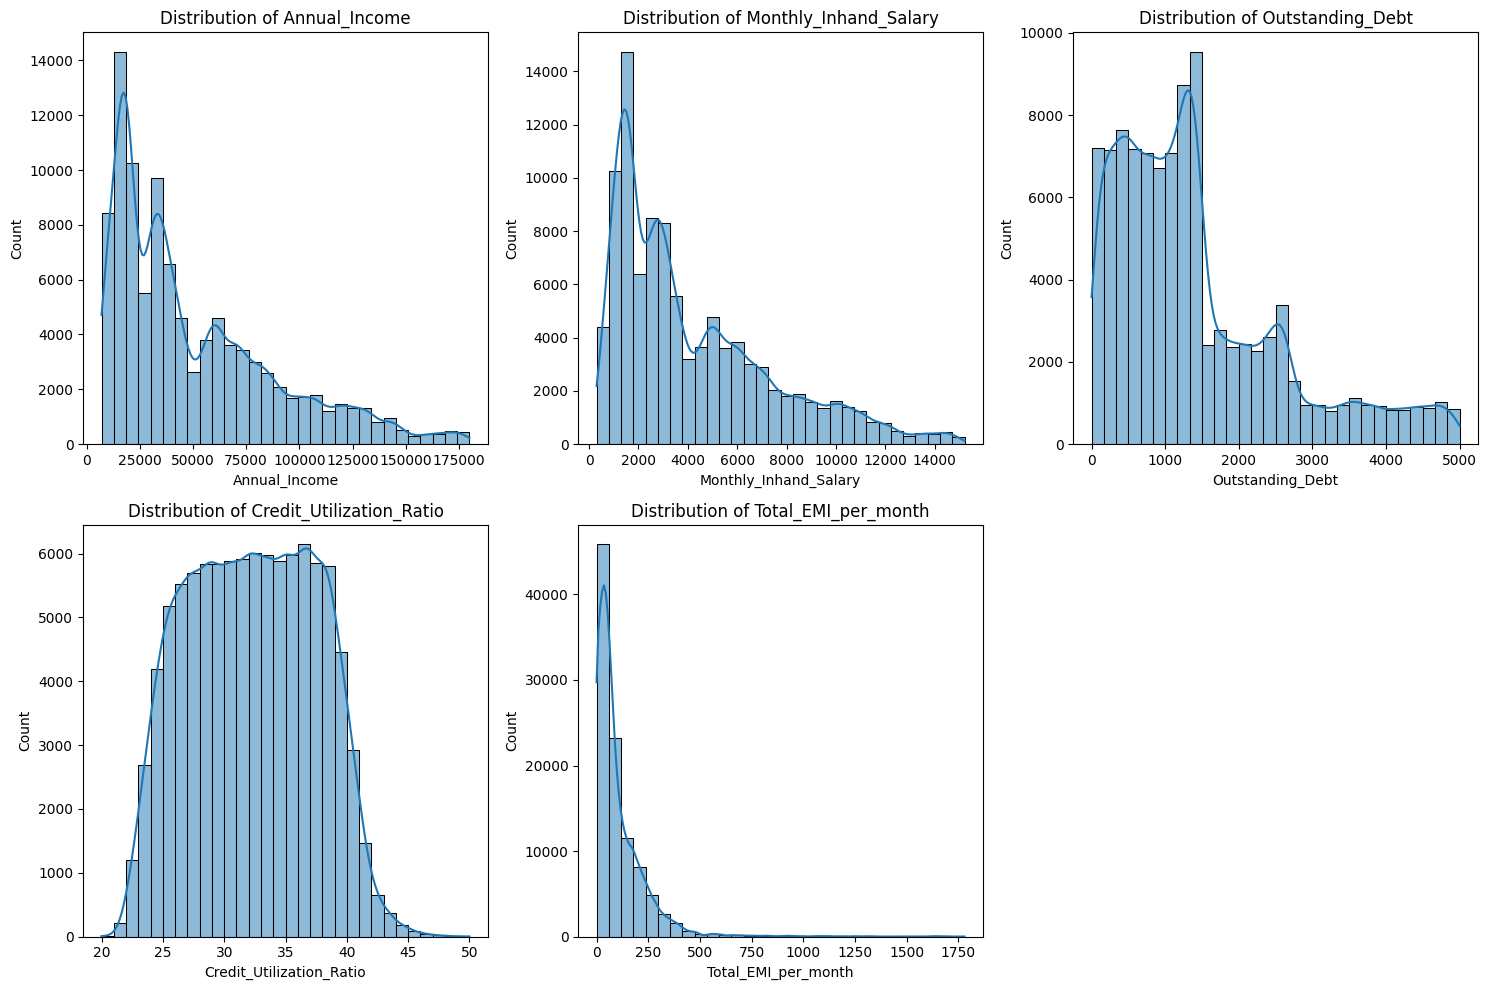

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

finance_cols = ['Annual_Income', 'Monthly_Inhand_Salary', 'Outstanding_Debt',
                'Credit_Utilization_Ratio', 'Total_EMI_per_month'] # 금융 수치 칼럼들을 따로 정리


plt.figure(figsize=(15, 10))
for i, col in enumerate(finance_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# 금융 관련 수치 데이트를 히스토그램으로 나타내보았고, 각 항목별로 비교 분석, 특정값에 쏠리거나 이상치가 있는지 탐wl
# 신용카드 사용 비율 외에는 도메인 특성상 그래프가 고르지 않은 것으로 보임

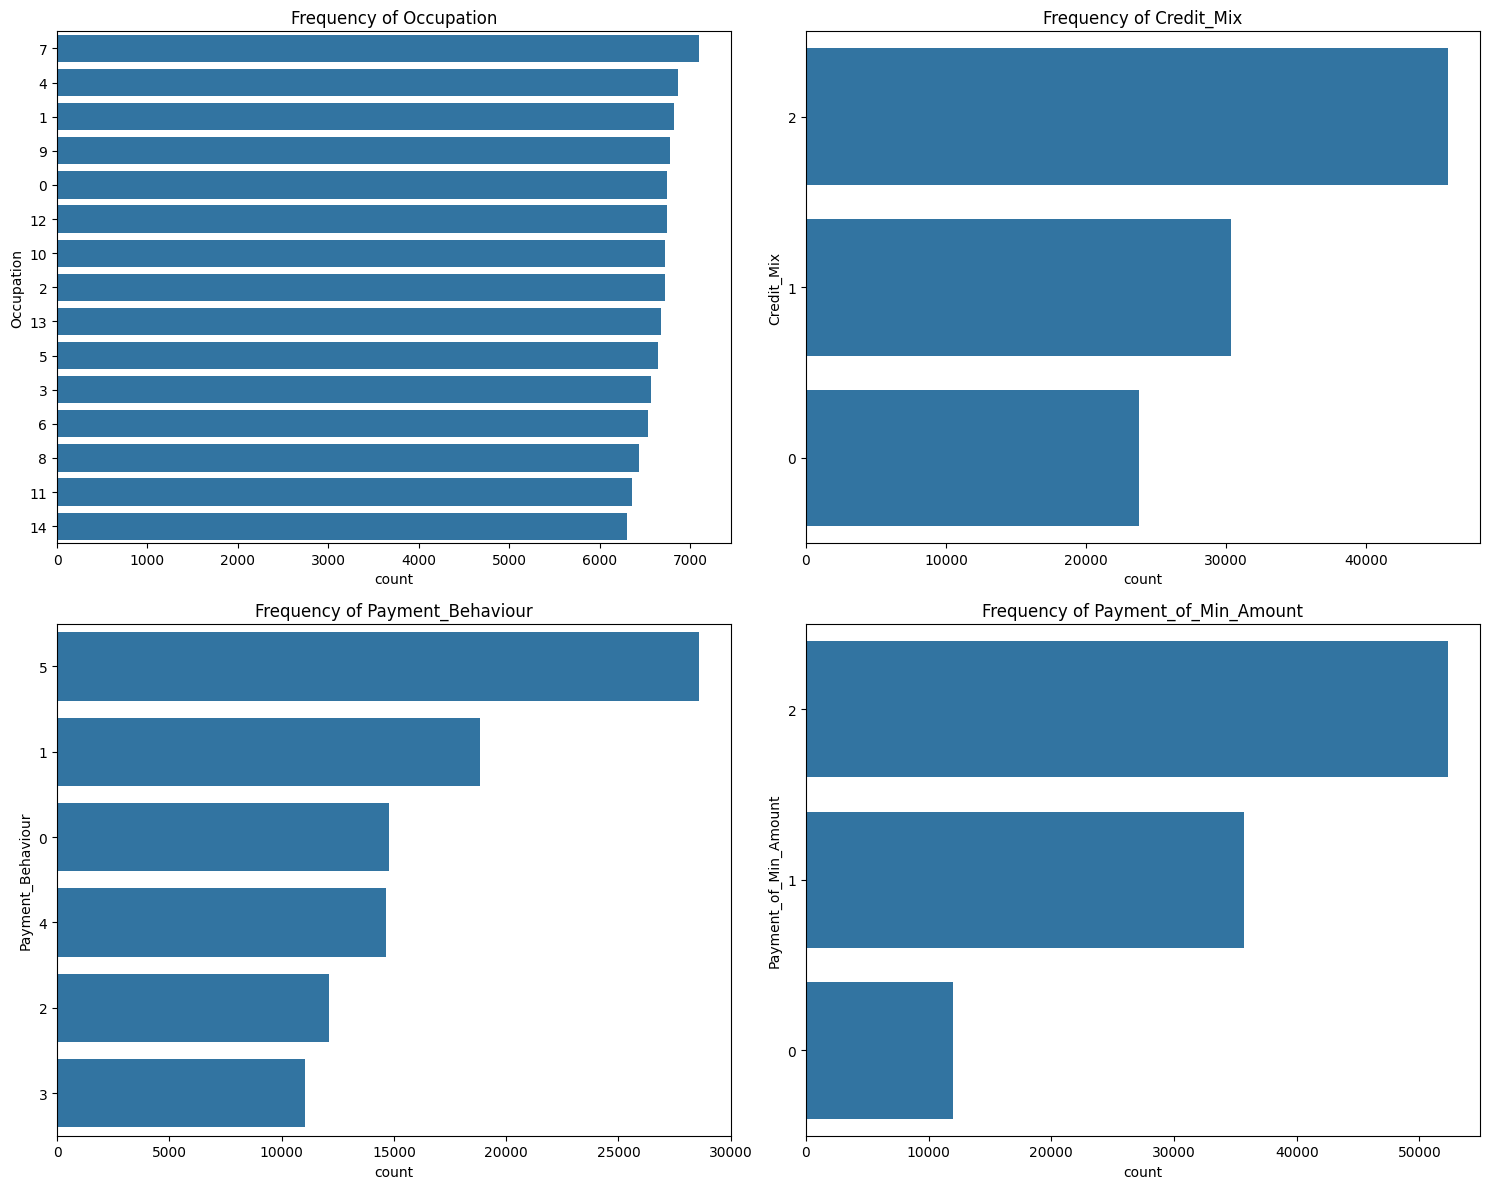

In [6]:
# 범주형 변수 시각화
cat_cols = ['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']

plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(y=data[col], order=data[col].value_counts().index)
    plt.title(f'Frequency of {col}')
plt.tight_layout()
plt.show()

# 직업군과 신용 등급, 지불 습관이 어떻게 분포되어 있는지 확인

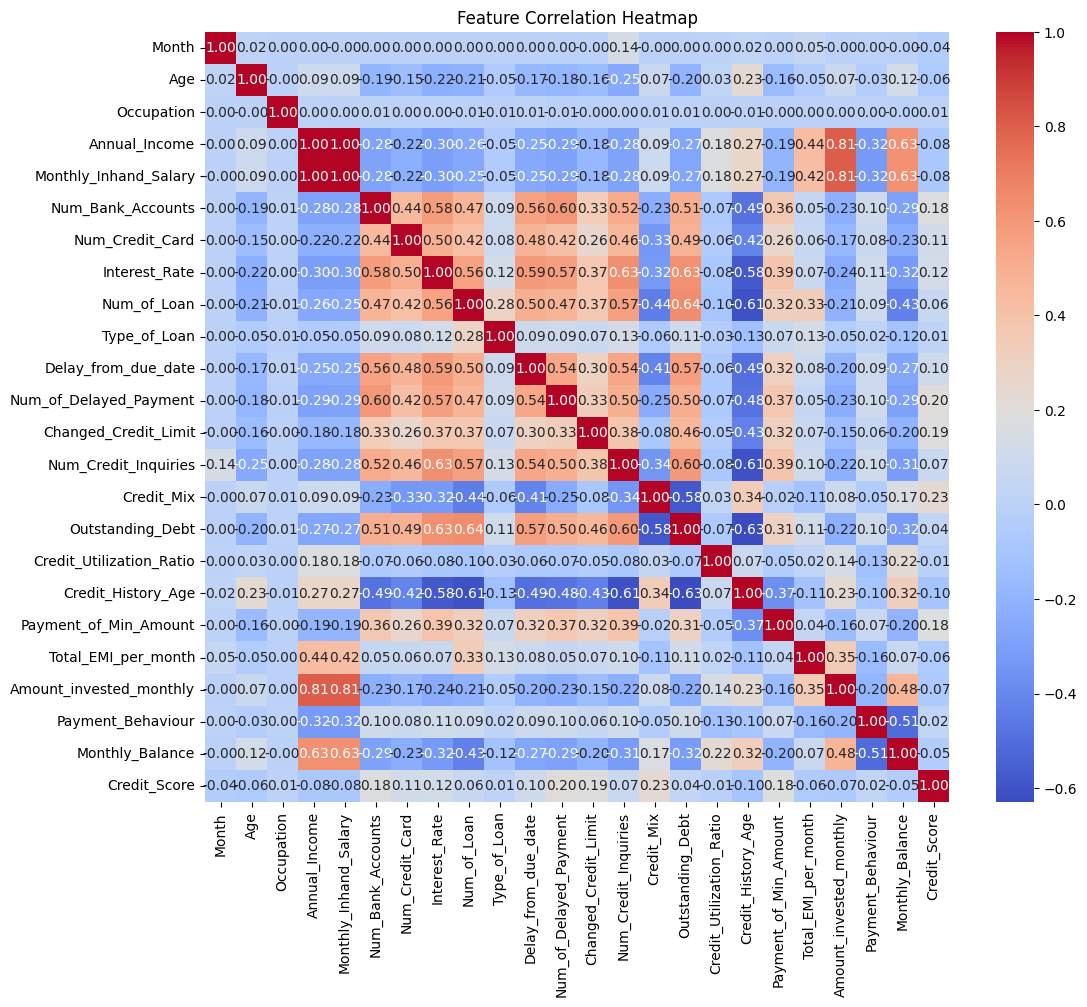

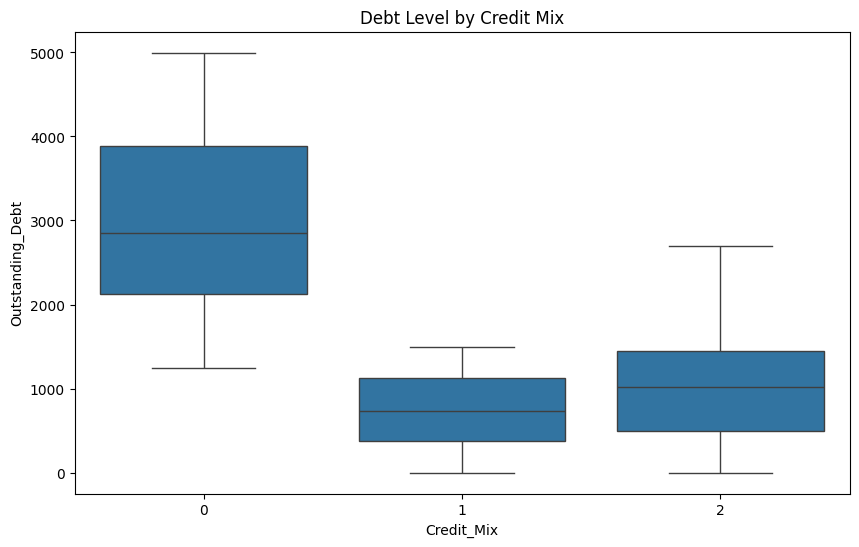

In [7]:
# 1. 수치형 변수 간 상관관계 히트맵
plt.figure(figsize=(12, 10))
corr = data.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

 # 수치형 변수간 상관관계를 분석해보았고,전체적인 특징으로는 대부분 변수들은 약한~중간 정도의 상관관계를 가진다는 것이었다.
# 일부 금융 변수들 사이에서는 강한 양(+)의 상관관계와 강한 음(-)의 상관관계가 존재
# 특히:대출/연체 관련 변수끼리 강한 양의 상관
# 신용이력(Credit_History_Age)은 부채 및 위험 변수와 음의 상관
# 소득 관련 변수끼리는 매우 강한 양의 상관

#  Outstanding_Debt ↔ Num_of_Loan의 경우 상관계수 ≈ 0.64가 나왔고 대출 건수가 많을수록 미상환 부채가 증가한다는 것을 확인할 수 있다.
# 반면에 Credit_History_Age ↔ Outstanding_Debt는 상관계수 ≈ -0.63이 나왔는데, 신용 이력이 오래될수록 미상환 부채가 감소할 수 있따는 것을 의미한다.

# 2. 신용 등급(Credit_Mix)에 따른 부채 수준 비교 [cite: 20]
plt.figure(figsize=(10, 6))
sns.boxplot(data, x='Credit_Mix', y='Outstanding_Debt')
plt.title('Debt Level by Credit Mix')
plt.show()

# credit_MIX의 경우 0, 1,2 로 나뉘어지는데
# 0은 전반적으로 부채가 많고, 사람들 간 부채 차이도 큰 편
# 1은 부채가 적고 비교적 균일한 패턴
# 2는 평균적으로는 중간 수준의 부채 상태지만, 일부는 높은 부채를 보유를 의미한다.

#뿐만 아니라 Credit_Mix가 Outstanding_Debt와 강한 관계가 있음을 보여준다.

#즉, 신용 조합 유형이 달라질수록 부채 수준 분포도 달라진다는 것을 알 수 있다.

In [8]:
# 데이터 전처리

log_cols = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly'
]

for col in log_cols:
    data[f'{col}_log'] = np.log1p(data[col])


In [9]:
q1 = data[col].quantile(0.01)
q99 = data[col].quantile(0.99)

data[col] = data[col].clip(q1, q99)

In [15]:
import pandas as pd
import numpy as np
import warnings
import torch
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, QuantileTransformer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
from lightgbm import LGBMClassifier

#
# [Step 1] 데이터 로드 및 파생변수 생성
#
df = pd.read_csv('train2.csv')
df = df.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

#  파생변수 생성 (총 16개)
df['Debt_to_Income']      = df['Outstanding_Debt']       / (df['Annual_Income']          + 1e-6)
df['EMI_Load_Ratio']      = df['Total_EMI_per_month']    / (df['Monthly_Inhand_Salary']  + 1e-6)
df['Cash_Flow_Ratio']     = df['Monthly_Balance']        / (df['Monthly_Inhand_Salary']  + 1e-6)
df['Invest_Ratio']        = df['Amount_invested_monthly']/ (df['Monthly_Inhand_Salary']  + 1e-6)
df['Balance_to_Debt']     = df['Monthly_Balance']        / (df['Outstanding_Debt']       + 1)
df['Income_per_Account']  = df['Annual_Income']          / (df['Num_Bank_Accounts']      + 1)
df['Credit_per_Loan']     = df['Changed_Credit_Limit']   / (df['Num_of_Loan']            + 1)
df['Loan_per_Account']    = df['Num_of_Loan']            / (df['Num_Bank_Accounts']      + 1)
df['Inquiry_per_Card']    = df['Num_Credit_Inquiries']   / (df['Num_Credit_Card']        + 1)

df['Age_x_History']       = df['Age']                    *  df['Credit_History_Age']
df['Util_x_Inquiry']      = df['Credit_Utilization_Ratio'] * df['Num_Credit_Inquiries']
df['EMI_x_Delay']         = df['Total_EMI_per_month']    *  df['Delay_from_due_date']
df['Inquiry_Debt_Interact']= df['Num_Credit_Inquiries']  *  df['Outstanding_Debt']
df['Delay_Risk_Score']    = df['Num_of_Delayed_Payment'] *  df['Delay_from_due_date']
df['Risk_Score']          = df['Delay_Risk_Score']       *  df['Debt_to_Income']
df['Loan_Type_Count']     = (df['Type_of_Loan'].fillna('')
                             .apply(lambda x: len([i for i in x.split(',')
                                                   if i.strip() not in ['','No Data','not specified']])))

# [로그 변환 및 이상치 클리핑]
log_cols = ['Annual_Income','Monthly_Inhand_Salary','Outstanding_Debt',
            'Total_EMI_per_month','Amount_invested_monthly']
for col in log_cols:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))

clip_cols = log_cols + ['Delay_Risk_Score','Risk_Score','Debt_to_Income',
                         'EMI_Load_Ratio','Cash_Flow_Ratio','Util_x_Inquiry','EMI_x_Delay']
for col in clip_cols:
    q1, q99 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col]  = df[col].clip(q1, q99)

# [범주형 인코딩]
cat_cols = ['Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df['Type_of_Loan_enc'] = LabelEncoder().fit_transform(df['Type_of_Loan'].astype(str))
df = df.drop(columns=['Type_of_Loan','Credit_History_Age'])
cat_cols.append('Type_of_Loan_enc') # 모델 학습 시 카테고리 지정 위해 추가

# [Month 순환 인코딩]
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df = df.drop(columns=['Month'])

# 타겟 분리 및 [개선] 데이터 스케일링
target_encoder = LabelEncoder()
df['Credit_Score'] = target_encoder.fit_transform(df['Credit_Score'])
X_raw = df.drop('Credit_Score', axis=1)
y     = df['Credit_Score'].values

# [핵심] TabNet을 위한 수치형 피처 비선형 정규분포화 (Quantile Transformer)
numeric_cols = [c for c in X_raw.columns if c not in cat_cols + ['Month_sin', 'Month_cos']]
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_raw[numeric_cols] = qt.fit_transform(X_raw[numeric_cols])

#
# [Feature Selection] Mutual Information 기반
#
mi_scores = mutual_info_classif(X_raw.values, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_raw.columns).sort_values(ascending=False)

selected_features = mi_series[mi_series > 0].index.tolist()
print(f"✔ 선택 피처 수: {len(selected_features)} / {X_raw.shape[1]}")

X = X_raw[selected_features].values.astype(np.float32)

# Train / Val 분리
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

cat_idxs, cat_dims = [], []
for i, col in enumerate(selected_features):
    if col in cat_cols:
        cat_idxs.append(i)
        cat_dims.append(int(X_raw[col].nunique()))

# [개선①] TabNet 비지도 사전학습 (Pre-training)
print("\n[TabNet] 사전학습 시작 (Self-supervised Learning)...")
unsupervised_model = TabNetPretrainer(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=10,
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax',
    n_shared=2,
    n_independent=2,
    device_name='auto'
)

unsupervised_model.fit(
    X_train=X_train,
    eval_set=[X_val],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    pretraining_ratio=0.8 # 데이터 80% 마스킹 복구
)


# [개선②] TabNet 본 학습 (Fine-tuning 및 파라미터 조정)
print("\n[TabNet] 본 학습 시작 (Fine-tuning)...")
clf_tabnet = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=10,
    n_d=32, n_a=32,        # 64 -> 32 축소 (과적합 방지)
    n_steps=5,             # 6 -> 5 축소
    gamma=1.3,             # 1.5 -> 1.3
    lambda_sparse=1e-2,    # 1e-3 -> 1e-2 (희소성 대폭 강화)
    optimizer_fn=torch.optim.AdamW,
    optimizer_params=dict(lr=2e-2, weight_decay=1e-5), # NAdam -> AdamW
    scheduler_fn=torch.optim.lr_scheduler.CosineAnnealingLR, # Changed back to CosineAnnealingLR
    scheduler_params=dict(T_max=50, eta_min=1e-4),     # Parameters for CosineAnnealingLR
    mask_type='entmax',
    seed=42,
    device_name='auto'
)

clf_tabnet.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=200,
    patience=25,
    batch_size=1024,
    virtual_batch_size=128,
    weights=1,
    from_unsupervised=unsupervised_model # 사전학습 가중치 로드
)

#
# [개선③] LightGBM 학습
#
print("\n[LightGBM] 학습 시작...")
clf_lgb = LGBMClassifier(
    n_estimators=2000,
    max_depth=8,
    learning_rate=0.03,
    num_leaves=127,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
clf_lgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[])

# [개선④] 소프트 보팅 앙상블 비중 최적화 Search
print("\n[Ensemble] 최적 가중치 탐색 시작...")
tabnet_proba = clf_tabnet.predict_proba(X_val)
lgb_proba    = clf_lgb.predict_proba(X_val)

best_acc = 0
best_weight = 0

# 0.0 ~ 1.0 사이에서 0.1 단위로 최적의 앙상블 비율 탐색
for w in np.linspace(0, 1, 11):
    mixed_proba = (w * tabnet_proba) + ((1 - w) * lgb_proba)
    curr_acc = accuracy_score(y_val, np.argmax(mixed_proba, axis=1))
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_weight = w

ensemble_proba = (best_weight * tabnet_proba) + ((1 - best_weight) * lgb_proba)
ensemble_pred  = np.argmax(ensemble_proba, axis=1)

print(f"✔ 찾은 최적 앙상블 비중 -> TabNet {best_weight:.1f} : LightGBM {1-best_weight:.1f}")


#  ■ 5. Validation Score 출력

tabnet_val_acc  = accuracy_score(y_val, clf_tabnet.predict(X_val))  * 100
lgb_val_acc     = accuracy_score(y_val, clf_lgb.predict(X_val))     * 100
ensemble_val_acc= accuracy_score(y_val, ensemble_pred)              * 100

tabnet_f1       = f1_score(y_val, clf_tabnet.predict(X_val),  average='macro') * 100
lgb_f1          = f1_score(y_val, clf_lgb.predict(X_val),     average='macro') * 100
ensemble_f1     = f1_score(y_val, ensemble_pred,              average='macro') * 100

train_acc_tabnet= accuracy_score(y_train, clf_tabnet.predict(X_train)) * 100

print("\n" + "=" * 65)
print("  ■ Validation Score 비교")
print("=" * 65)
print(f"  [TabNet 단독]          Val Accuracy: {tabnet_val_acc:>6.2f}%  Macro F1: {tabnet_f1:.2f}%")
print(f"  [LightGBM 단독]        Val Accuracy: {lgb_val_acc:>6.2f}%  Macro F1: {lgb_f1:.2f}%")
print(f"  [최적 앙상블]          Val Accuracy: {ensemble_val_acc:>6.2f}%  Macro F1: {ensemble_f1:.2f}%  ← 최종")
print(f"  TabNet 과적합 갭       Train-Valid : {train_acc_tabnet - tabnet_val_acc:.2f}%p")
print("=" * 65)

print("\n  [Classification Report — 앙상블 Validation]")
print(classification_report(y_val, ensemble_pred, target_names=target_encoder.classes_))

✔ 선택 피처 수: 42 / 44

[TabNet] 사전학습 시작 (Self-supervised Learning)...
epoch 0  | loss: 1.57387 | val_0_unsup_loss_numpy: 0.7936300039291382|  0:00:04s
epoch 1  | loss: 0.81477 | val_0_unsup_loss_numpy: 0.698989987373352|  0:00:09s
epoch 2  | loss: 0.74197 | val_0_unsup_loss_numpy: 0.6213799715042114|  0:00:14s
epoch 3  | loss: 0.68252 | val_0_unsup_loss_numpy: 0.5565699934959412|  0:00:18s
epoch 4  | loss: 0.63881 | val_0_unsup_loss_numpy: 0.5194399952888489|  0:00:23s
epoch 5  | loss: 0.61575 | val_0_unsup_loss_numpy: 0.5013099908828735|  0:00:28s
epoch 6  | loss: 0.60122 | val_0_unsup_loss_numpy: 0.4832499921321869|  0:00:33s
epoch 7  | loss: 0.58896 | val_0_unsup_loss_numpy: 0.4760499894618988|  0:00:38s
epoch 8  | loss: 0.58662 | val_0_unsup_loss_numpy: 0.4698300063610077|  0:00:42s
epoch 9  | loss: 0.57801 | val_0_unsup_loss_numpy: 0.4634299874305725|  0:00:48s
epoch 10 | loss: 0.57282 | val_0_unsup_loss_numpy: 0.4614799916744232|  0:00:53s
epoch 11 | loss: 0.56879 | val_0_unsup_loss